In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Set plotting style
sns.set_style("whitegrid")
file_path = 'synthetic_mimic_ed_data.csv'
df = pd.read_csv(file_path)

# Convert time columns to datetime objects
df['intime'] = pd.to_datetime(df['intime'])
df['outtime'] = pd.to_datetime(df['outtime'])

# Calculate Length of Stay (LOS) in hours - a key feature
df['los_hrs'] = (df['outtime'] - df['intime']).dt.total_seconds() / 3600

# Drop original time columns
df = df.drop(columns=['intime', 'outtime'])

print("--- Initial Data Information ---")
df.info()
print("\n--- Data after LOS Calculation (Sample) ---")
print(df[['stay_id', 'los_hrs']].head().to_markdown(index=False))

--- Initial Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   subject_id        10000 non-null  int64  
 1   stay_id           10000 non-null  int64  
 2   gender            10000 non-null  object 
 3   race              10000 non-null  object 
 4   age               10000 non-null  int64  
 5   chief_complaint   10000 non-null  object 
 6   pain              10000 non-null  object 
 7   acuity_mts_level  10000 non-null  int64  
 8   icu_stay_flag     10000 non-null  int64  
 9   time_to_icu_hrs   314 non-null    float64
 10  icd_code          10000 non-null  object 
 11  hr_initial        10000 non-null  int64  
 12  rr_initial        10000 non-null  int64  
 13  sbp_min           10000 non-null  int64  
 14  o2sat_min         10000 non-null  int64  
 15  temp_initial      10000 non-null  float64
 16  los_hrs 

/tmp/ipython-input-1025398008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='acuity_mts_level', data=df, order=sorted(df['acuity_mts_level'].unique()), palette='viridis')


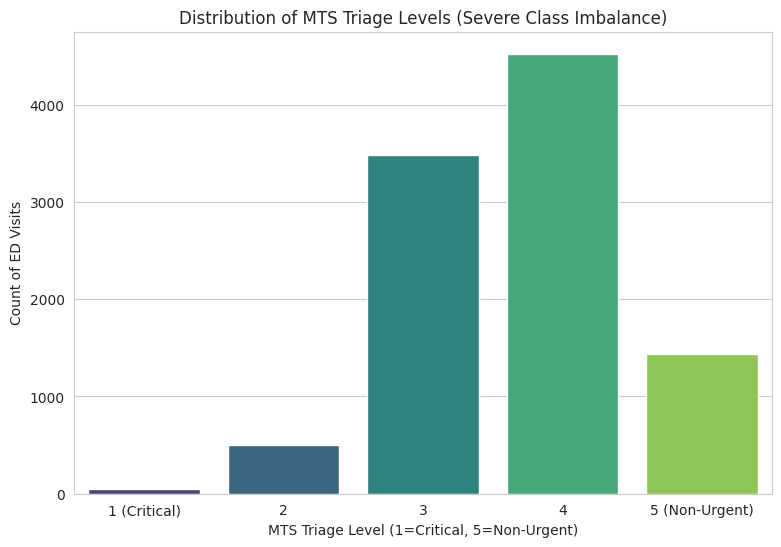

In [ ]:
# Cell 2: Visualization - Class Imbalance (Acuity Level)
plt.figure(figsize=(9, 6))
# Using a specific color palette for visual appeal
sns.countplot(x='acuity_mts_level', data=df, order=sorted(df['acuity_mts_level'].unique()), palette='viridis')
plt.title('Distribution of MTS Triage Levels (Severe Class Imbalance)')
plt.xlabel('MTS Triage Level (1=Critical, 5=Non-Urgent)')
plt.ylabel('Count of ED Visits')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['1 (Critical)', '2', '3', '4', '5 (Non-Urgent)'])
plt.show()

/tmp/ipython-input-986972446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='Pastel1')
/tmp/ipython-input-986972446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='Pastel1')
/tmp/ipython-input-986972446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='Pastel1')
/tmp/ipython-input-986972446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effec

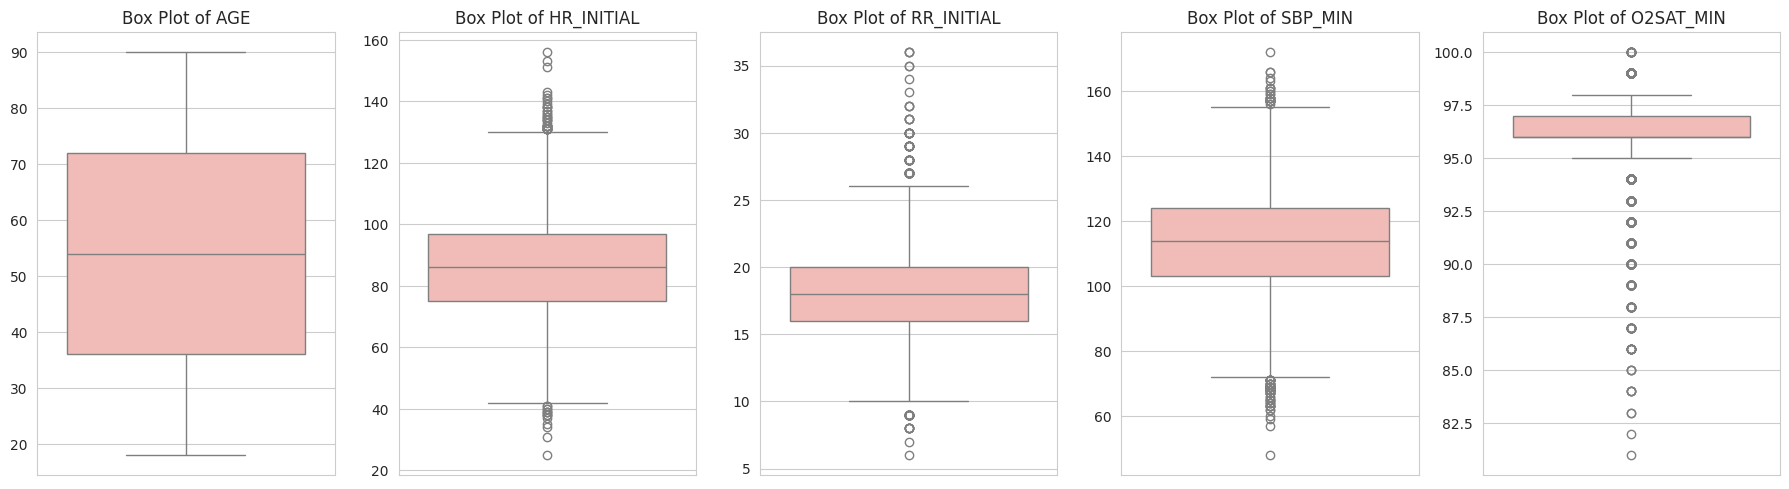

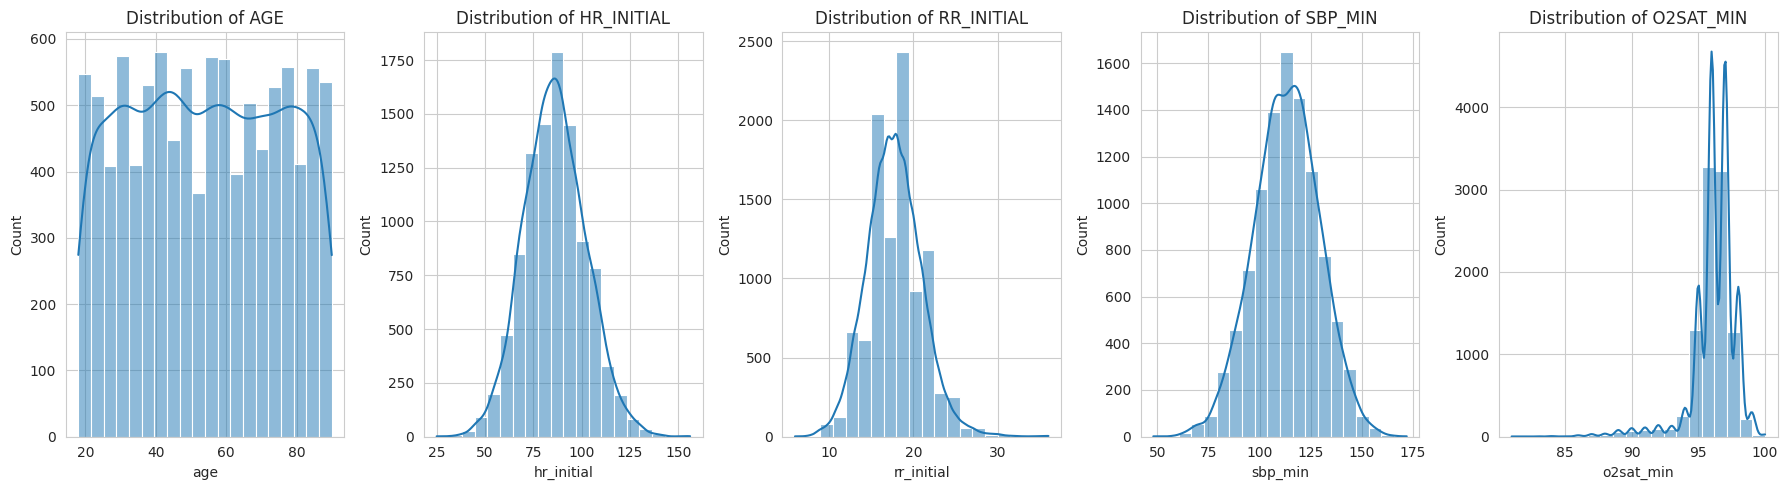

In [ ]:
# Cell 3: Visualization - Numerical Feature Spread (Vitals)
vitals_to_plot = ['age', 'hr_initial', 'rr_initial', 'sbp_min', 'o2sat_min']

# Box plots for outlier detection and spread comparison
plt.figure(figsize=(18, 5))
for i, col in enumerate(vitals_to_plot):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(y=df[col], palette='Pastel1')
    plt.title(f'Box Plot of {col.upper()}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Histograms for distribution shape
plt.figure(figsize=(18, 5))
for i, col in enumerate(vitals_to_plot):
    plt.subplot(1, 5, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col.upper()}')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Preprocessing - Categorical Feature Encoding
from sklearn.preprocessing import LabelEncoder

# Label encode 'gender' (binary)
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

# One-hot encode categorical features ('race', 'pain', etc.)
# We drop the first category of each to prevent multicollinearity
df_encoded = pd.get_dummies(df, columns=['race', 'pain', 'icd_code'], drop_first=True)

print("\n--- Data after Categorical Encoding (Partial Sample) ---")
print(df_encoded[['gender_encoded',
                  'race_Hispanic',
                  'pain_4/10 Mild',
                  'icd_code_J18.9',
                  'chief_complaint']].head().to_markdown(index=False))

print("\nPreprocessing complete. Data is ready for the next phase of Feature Engineering.")


--- Data after Categorical Encoding (Partial Sample) ---
|   gender_encoded | race_Hispanic   | pain_4/10 Mild   | icd_code_J18.9   | chief_complaint                                |
|-----------------:|:----------------|:-----------------|:-----------------|:-----------------------------------------------|
|                1 | False           | False            | False            | Routine check-up, non-urgent consultation.     |
|                0 | False           | False            | True             | Abdominal pain x 2 days, vomiting, stable.     |
|                0 | False           | True             | False            | Sore throat, wants rapid test.                 |
|                0 | False           | False            | False            | Mild back pain, needs a prescription refill.   |
|                1 | False           | False            | False            | Fever and cough, feels weak, able to ambulate. |

Preprocessing complete. Data is ready for the next phase of